# Task 1: Data Preparation


In [1]:
#importing data and replacing headers
import pandas as pd
#importing data and making the headers
data = pd.read_csv('School-Age-Digital-Connectivity-A1data.csv',header=None, names = ('ISO3', 
                'Countries and areas', 'Region', 'Sub-region','Income Group' , 'Total', 'Rural (Residence)', 
                'Urban (Residence)', 'Poorest (Wealth quintile)', 'Richest (Wealth quintile)',
                'Data source', 'Time period'))
data = data.drop(index=0)
data = data.drop(index=1)
#dropping columns
columns_to_drop = ['Data source', 'Region', 'Sub-region']
data = data.drop(columns=columns_to_drop)
data

,ISO3,Countries and areas,Income Group,Total,Rural (Residence),Urban (Residence),Poorest (Wealth quintile),Richest (Wealth quintile),Time period
2,DZA,Algeria,Upper middle income (UM),24%,9%,32%,1%,77%,2018-19
3,AGO,Angola,Lower middle income (LM),17%,2%,24%,0%,62%,2015-16
4,ARM,Armenia,Upper middle income (UM),81%,71%,88%,47%,99%,2015-16
5,BGD,Bangladesh,Lower middle income (LM),37%,33%,52%,9%,76%,2019
6,BRB,Barbados,High income (H),66%,61%,69%,10%,98%,2012
...,...,...,...,...,...,...,...,...,...
75,UGA,Uganda,Low income (L),0%,0%,2%,0%,2%,2015
76,UKR,Ukraine,Lower middle income (LM),71%,NaN,71%,NaN,NaN,2013
77,UZB,Uzbekistan,Lowerr middle income (LM),19%,16%,29%,1%,69%,2017
78,ZMB,Zambia,Lower middle income (LM),6%,2%,13%,0%,28%,2018-19


In [2]:
           #mistake 1- whitespace

In [3]:
# whitespace
for variables in data.columns:
    data[variables] = data[variables].str.strip() if data[variables].dtype == 'object' else data[variables]

In [4]:
          #mistake 2- impossible values(years greater than 2023)

In [5]:
#dropping row with impossible values
data = data.drop(index=65)
data = data.drop(index=51)

In [6]:
           #mistake 3- duplicates

In [7]:
#checking for duplicate rows
duplicates = data[data.duplicated()]
duplicates

,ISO3,Countries and areas,Income Group,Total,Rural (Residence),Urban (Residence),Poorest (Wealth quintile),Richest (Wealth quintile),Time period
72,TUR,Turkey,Upper middle income (UM),36%,14%,43%,2%,90%,2013
73,TUR,Turkey,Upper middle income (UM),36%,14%,43%,2%,90%,2013


In [8]:
#dropping the duplicate rows
data = data.drop(index=72)
data = data.drop(index=73)

In [9]:
            #mistake 4- input mistakes

In [10]:
#input mistakes(%%)
data.loc[:, 'Total'] = data.loc[:, 'Total'].str.replace('%%', '%')
data.loc[:, 'Urban (Residence)'] = data.loc[:, 'Urban (Residence)'].str.replace('%%', '%')

In [11]:
             #mistake 5- missing values 

In [12]:
#finding missing values
print(data.isna().sum())

ISO3                         0
Countries and areas          0
Income Group                 0
Total                        0
Rural (Residence)            2
Urban (Residence)            0
Poorest (Wealth quintile)    6
Richest (Wealth quintile)    7
Time period                  0
dtype: int64


In [13]:
#checking data types
data.dtypes

ISO3                         object
Countries and areas          object
Income Group                 object
Total                        object
Rural (Residence)            object
Urban (Residence)            object
Poorest (Wealth quintile)    object
Richest (Wealth quintile)    object
Time period                  object
dtype: object

In [14]:
#replace missing with mean
columns_missing = ['Rural (Residence)', 'Poorest (Wealth quintile)', 'Richest (Wealth quintile)']

for columns in columns_missing:
  data[columns] = data[columns].str.rstrip('%').astype(float)

column_means = data[columns_missing].mean()
data_cleaned = data.copy()
data_cleaned[columns_missing] = data_cleaned[columns_missing].fillna(column_means)                             
data_cleaned[columns_missing] = data_cleaned[columns_missing].applymap(lambda x: f"{x:.1f}%")

In [15]:
#checking missing values
print(data_cleaned.isna().sum())

ISO3                         0
Countries and areas          0
Income Group                 0
Total                        0
Rural (Residence)            0
Urban (Residence)            0
Poorest (Wealth quintile)    0
Richest (Wealth quintile)    0
Time period                  0
dtype: int64


In [16]:
           #mistake 6- spelling mistakes

In [17]:
#checking spelling mistakes
data_cleaned['Income Group'].value_counts()

Upper middle income (UM)     27
Lower middle income (LM)     26
Low income (L)               15
High income (H)               5
Lowerr middle income (LM)     1
Name: Income Group, dtype: int64

In [18]:
#fixing spelling mistakes
corrections = {'Lowerr middle income (LM)': 'Lower middle income (LM)'}
data_cleaned['Income Group'] = data_cleaned['Income Group'].replace(corrections)

In [19]:
#printing out all data
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
data_cleaned

,ISO3,Countries and areas,Income Group,Total,Rural (Residence),Urban (Residence),Poorest (Wealth quintile),Richest (Wealth quintile),Time period
2,DZA,Algeria,Upper middle income (UM),24%,9.0%,32%,1.0%,77.0%,2018-19
3,AGO,Angola,Lower middle income (LM),17%,2.0%,24%,0.0%,62.0%,2015-16
4,ARM,Armenia,Upper middle income (UM),81%,71.0%,88%,47.0%,99.0%,2015-16
5,BGD,Bangladesh,Lower middle income (LM),37%,33.0%,52%,9.0%,76.0%,2019
6,BRB,Barbados,High income (H),66%,61.0%,69%,10.0%,98.0%,2012
7,BEN,Benin,Low income (L),4%,1.0%,7%,0.0%,16.0%,2017-18
8,BOL,Bolivia,Lower middle income (LM),12%,4.0%,17%,19.0%,61.7%,2016
9,BIH,Bosnia and Herzegovina,Upper middle income (UM),59%,51.0%,76%,8.0%,96.0%,2011-12
10,BRA,Brazil,Upper middle income (UM),83%,51.0%,89%,84.0%,97.0%,2018
11,BGR,Bulgaria,Upper middle income (UM),76%,66.0%,81%,35.0%,97.0%,2013


In [20]:
number_of_rows = data_cleaned.shape[0]
print("Number of Rows:" ,number_of_rows)

Number of Rows: 74


In [21]:
#outliers- look at dominiaon republic 100% of rurual will not have internet 
#gambia 65% for a low income country



In [22]:
cleaned_A1data = data_cleaned

In [23]:
"""
Write dataframe object into a csv file
XXXXX.to_csv('XXXXX.csv', index=False)
Please replace XXXXX with your dataframe variable and name of the csv file.
"""
cleaned_A1data.to_csv('cleaned_A1data.csv', index=False)

# Task 2: Data Exploration

## Task 2.1 

In [24]:
import pandas as pd
data = pd.read_csv('cleaned_A1data.csv')
data

,ISO3,Countries and areas,Income Group,Total,Rural (Residence),Urban (Residence),Poorest (Wealth quintile),Richest (Wealth quintile),Time period
0,DZA,Algeria,Upper middle income (UM),24%,9.0%,32%,1.0%,77.0%,2018-19
1,AGO,Angola,Lower middle income (LM),17%,2.0%,24%,0.0%,62.0%,2015-16
2,ARM,Armenia,Upper middle income (UM),81%,71.0%,88%,47.0%,99.0%,2015-16
3,BGD,Bangladesh,Lower middle income (LM),37%,33.0%,52%,9.0%,76.0%,2019
4,BRB,Barbados,High income (H),66%,61.0%,69%,10.0%,98.0%,2012
5,BEN,Benin,Low income (L),4%,1.0%,7%,0.0%,16.0%,2017-18
6,BOL,Bolivia,Lower middle income (LM),12%,4.0%,17%,19.0%,61.7%,2016
7,BIH,Bosnia and Herzegovina,Upper middle income (UM),59%,51.0%,76%,8.0%,96.0%,2011-12
8,BRA,Brazil,Upper middle income (UM),83%,51.0%,89%,84.0%,97.0%,2018
9,BGR,Bulgaria,Upper middle income (UM),76%,66.0%,81%,35.0%,97.0%,2013


In [25]:
#converting data into integers
columns_to_convert = ['Total', 'Rural (Residence)', 'Urban (Residence)', 'Poorest (Wealth quintile)',
                      'Richest (Wealth quintile)']
data[columns_to_convert] = data[columns_to_convert].apply(lambda x: x.str.rstrip('%').astype(float) / 100.0)
data

,ISO3,Countries and areas,Income Group,Total,Rural (Residence),Urban (Residence),Poorest (Wealth quintile),Richest (Wealth quintile),Time period
0,DZA,Algeria,Upper middle income (UM),0.24,0.090,0.32,0.01,0.770,2018-19
1,AGO,Angola,Lower middle income (LM),0.17,0.020,0.24,0.00,0.620,2015-16
2,ARM,Armenia,Upper middle income (UM),0.81,0.710,0.88,0.47,0.990,2015-16
3,BGD,Bangladesh,Lower middle income (LM),0.37,0.330,0.52,0.09,0.760,2019
4,BRB,Barbados,High income (H),0.66,0.610,0.69,0.10,0.980,2012
5,BEN,Benin,Low income (L),0.04,0.010,0.07,0.00,0.160,2017-18
6,BOL,Bolivia,Lower middle income (LM),0.12,0.040,0.17,0.19,0.617,2016
7,BIH,Bosnia and Herzegovina,Upper middle income (UM),0.59,0.510,0.76,0.08,0.960,2011-12
8,BRA,Brazil,Upper middle income (UM),0.83,0.510,0.89,0.84,0.970,2018
9,BGR,Bulgaria,Upper middle income (UM),0.76,0.660,0.81,0.35,0.970,2013


In [26]:
#means for ech of the columns
means = ['Total', 'Rural (Residence)', 'Poorest (Wealth quintile)', 'Richest (Wealth quintile)']
means = data[means].mean()
means

Total                        0.352297
Rural (Residence)            0.278892
Poorest (Wealth quintile)    0.190270
Richest (Wealth quintile)    0.616878
dtype: float64

Text(0.5, 0.98, '')

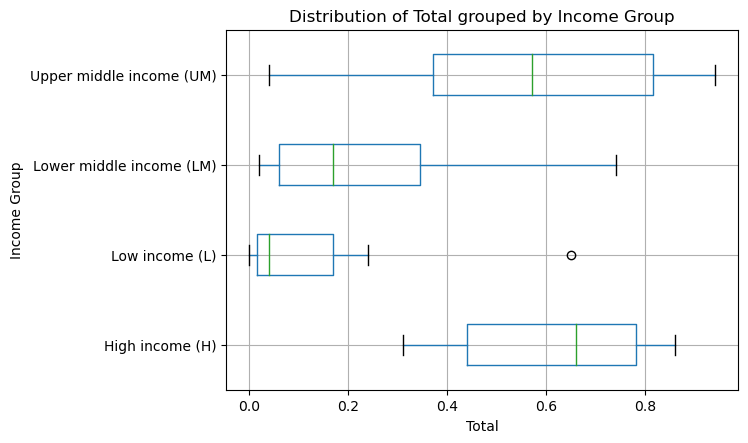

In [27]:
#side by side boxplot for Total grouped by Income Group
import matplotlib.pyplot as plt
data.boxplot(column='Total', by='Income Group', vert=False)
plt.title('Distribution of Total grouped by Income Group')
plt.xlabel('Total')
plt.ylabel('Income Group')
plt.suptitle('')

In [28]:
#mean for each Income Group in total
group = ['Income Group', 'Total']
collective = data[group]
mean_income = collective.groupby('Income Group')['Total'].mean()
mean_income

Income Group
High income (H)             0.610000
Low income (L)              0.117333
Lower middle income (LM)    0.227037
Upper middle income (UM)    0.560370
Name: Total, dtype: float64

## Task 2.2 

In [29]:
#median for rural
median_rural = data['Rural (Residence)'].median()
median_rural = median_rural * 100
median_rural

13.5

In [30]:
#median for urban
median_urban = data['Urban (Residence)'].median()
median_urban = median_urban * 100
median_urban

40.5

In [31]:
#top ten for rural
top_ruralcountries = data.nlargest(10, 'Rural (Residence)')
columns_to_select = ['ISO3', 'Countries and areas', 'Rural (Residence)']
top_ruralcountries = top_ruralcountries[columns_to_select]
top_ruralcountries

,ISO3,Countries and areas,Rural (Residence)
22,DOM,Dominican Republic,1.00
55,SRB,Serbia,0.91
62,MKD,North Macedonia,0.90
64,TON,Tonga,0.90
33,JPN,Japan,0.83
51,RUS,Russian Federation,0.79
46,MNE,Montenegro,0.74
25,GEO,Georgia,0.72
2,ARM,Armenia,0.71
14,CHL,Chile,0.70


In [32]:
#top ten for urban
top_urbancountries = data.nlargest(10, 'Urban (Residence)')
columns_to_select = ['ISO3', 'Countries and areas', 'Urban (Residence)']
top_urbancountries = top_urbancountries[columns_to_select]
top_urbancountries

,ISO3,Countries and areas,Urban (Residence)
55,SRB,Serbia,0.97
51,RUS,Russian Federation,0.94
64,TON,Tonga,0.94
25,GEO,Georgia,0.93
62,MKD,North Macedonia,0.93
15,CHN,China,0.91
8,BRA,Brazil,0.89
14,CHL,Chile,0.89
2,ARM,Armenia,0.88
46,MNE,Montenegro,0.86


## Task 2.3 

In [33]:
wealth_stats = data[['Poorest (Wealth quintile)', 'Richest (Wealth quintile)']] * 100
wealth_stats = wealth_stats.describe().round(3)
wealth_stats

,Poorest (Wealth quintile),Richest (Wealth quintile)
count,74.000,74.000
mean,19.027,61.688
std,26.631,33.166
min,0.000,0.000
25%,0.000,34.500
50%,6.000,67.000
75%,22.750,93.000
max,100.000,100.000


In [34]:
median = wealth_stats.median().round(3)
median

Poorest (Wealth quintile)    20.888
Richest (Wealth quintile)    64.344
dtype: float64